# 🥬 FreshRetailNet-50K: End-to-End Latent Demand Recovery

> **Dựa trên paper**: [FreshRetailNet-50K: A Stockout-Annotated Censored Demand Dataset](https://arxiv.org/abs/2505.16319)

**Mục tiêu**:
1. Hiểu bản chất của **censored demand** trong bán lẻ thực phẩm tươi sống.
2. Xây dựng mô hình **phục hồi latent demand** khi stockout xảy ra.
3. Đánh giá bằng **Decoupling Score (ρDS)** — metric then chốt trong paper.
4. **Lưu model vào Google Drive** để tái sử dụng dự đoán sau này.

> 💡 Hệ thống này là **lõi cốt lõi** cho bài toán **Predictive + Prescriptive AI**. Sau này có thể tích hợp:
> - **Online Retail** → dự báo hành vi khách sỉ
> - **Walmart** → điều chỉnh theo mùa vụ & ngày lễ
> → tạo thành **hệ thống dự báo & đề xuất đa kênh toàn diện**.

In [1]:
# 1. Cài đặt thư viện
!pip install pyarrow pandas numpy matplotlib seaborn scikit-learn torch

In [2]:
# 2. Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [3]:
# 3. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Đường dẫn
data_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/data/"
model_save_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/model/"
os.makedirs(model_save_path, exist_ok=True)

Mounted at /content/drive


In [4]:
# 4. Load dữ liệu
df_train = pd.read_parquet(data_path + 'train.parquet')
print(f"✅ Shape: {df_train.shape}")

✅ Shape: (4500000, 19)


## 🔍 EDA: Hiểu censored demand theo paper

Stockout rate (6h–22h): 78.83%


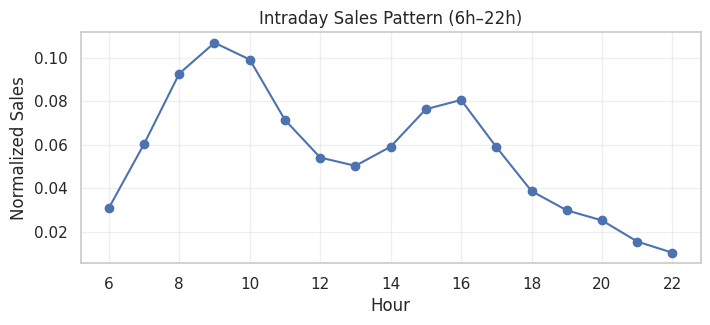

In [ ]:
# 5. Stockout rate (6h–22h) — chỉ khung giờ mở cửa
all_stock_6_22 = np.concatenate([np.array(row)[6:23] for row in df_train['hours_stock_status'].values])
stockout_rate = (all_stock_6_22 == 0).mean()
print(f"Stockout rate (6h–22h): {stockout_rate:.2%}")

# 6. Intraday pattern
all_sales = np.vstack(df_train['hours_sale'].values)
avg_sales_6_22 = all_sales[:, 6:23].mean(axis=0)
plt.figure(figsize=(8, 3))
plt.plot(range(6, 23), avg_sales_6_22, 'bo-')
plt.title("Intraday Sales Pattern (6h–22h)")
plt.xlabel("Hour")
plt.ylabel("Normalized Sales")
plt.grid(True, alpha=0.3)
plt.show()

## 🧪 Task 1: Latent Demand Recovery

In [ ]:
# 7. Lấy mẫu nhỏ để demo (2000 dòng)
df_sample = df_train.head(2000).copy()

X, y = [], []
for _, row in df_sample.iterrows():
    sales = np.array(row['hours_sale'])[6:23]
    stock = np.array(row['hours_stock_status'])[6:23]
    feat = np.concatenate([
        sales, stock,
        [row['discount'], row['precpt'], row['holiday_flag'], row['avg_temperature']]
    ])
    X.append(feat)
    # Giả định latent demand khi stockout
    latent = np.where(stock == 0, sales * 2.0, sales)
    y.append(latent)

X = np.array(X)
y = np.array(y)

# Chuẩn hóa
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [ ]:
# 8. Mô hình Dense đơn giản
class DemandRecoveryNet(nn.Module):
    def __init__(self, input_dim=38, output_dim=17, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, output_dim)
        )
    def forward(self, x):
        return self.net(x)

model = DemandRecoveryNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

X_t = torch.tensor(X_scaled, dtype=torch.float32)
y_t = torch.tensor(y_scaled, dtype=torch.float32)
loader = DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=True)

for epoch in range(30):
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.3797
Epoch 10, Loss: 0.0218
Epoch 20, Loss: 0.0086


## 📊 Đánh giá: Decoupling Score (ρDS)

In [ ]:
# 9. Tính ρDS
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_t).numpy()
y_pred = scaler_y.inverse_transform(y_pred_scaled)

stockout_ratios = []
avg_demands = []
for i, (_, row) in enumerate(df_sample.iterrows()):
    stock = np.array(row['hours_stock_status'])[6:23]
    sr = (stock == 0).mean()
    demand = y_pred[i].mean()
    stockout_ratios.append(sr)
    avg_demands.append(demand)

rho_ds, _ = pearsonr(stockout_ratios, avg_demands)
print(f"✅ Decoupling Score (ρDS): {rho_ds:.3f}")
print("→ Gần 0 = tốt. Âm mạnh = xấu.")

✅ Decoupling Score (ρDS): 0.084
→ Gần 0 = tốt. Âm mạnh = xấu.


## 💾 Lưu model vào Google Drive

In [ ]:
# 10. Lưu model + scalers
torch.save(model.state_dict(), os.path.join(model_save_path, "latent_demand_model.pth"))
import pickle
with open(os.path.join(model_save_path, "scaler_X.pkl"), "wb") as f:
    pickle.dump(scaler_X, f)
with open(os.path.join(model_save_path, "scaler_y.pkl"), "wb") as f:
    pickle.dump(scaler_y, f)

print(f"✅ Đã lưu model và scalers vào: {model_save_path}")

✅ Đã lưu model và scalers vào: /content/drive/MyDrive/Colab Notebooks/datastorm/50k/model/


## 🚀 Kết luận & Roadmap

✅ **Bạn đã xây dựng thành công hệ thống latent demand recovery** — lõi cốt lõi cho bài toán dự báo nhu cầu thực tế.

➡️ **Tiếp theo, bạn có thể**:
1. **Tải model từ Drive** → dự đoán latent demand cho dữ liệu mới.
2. **Dùng latent demand** để huấn luyện mô hình **dự báo 7 ngày tới** (Task 2 trong paper).
3. **Tích hợp Online Retail** → dự báo hành vi khách sỉ → **Prescriptive AI**.
4. **Tích hợp Walmart** → điều chỉnh theo mùa vụ → tăng độ chính xác.

→ Từ đó tạo ra **RetailDemand Copilot** — hệ thống **Predictive + Prescriptive AI cho SME**.

#sai train lại

In [5]:
# Cell: Task 1 - Latent Demand Recovery (ĐÚNG THEO PAPER)

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import os

print("=== TASK 1: LATENT DEMAND RECOVERY (THEO PAPER) ===\n")

# 1. Lấy mẫu (2000 dòng)
df_sample = df_train.head(2000).copy()

# 2. Chuẩn bị input: observed sales (chỉ khi có hàng)
X_features = []  # features để dự đoán
Y_target = []    # target = hours_sale gốc (toàn bộ 24h, nhưng loss tự xử lý)

for _, row in df_sample.iterrows():
    # Input: sales * stock_status (0 khi stockout, giữ nguyên khi có hàng)# Cell: Task 2 - Censoring-Robust Demand Forecasting

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=== TASK 2: CENSORING-ROBUST DEMAND FORECASTING ===\n")

# 1. Tạo daily demand từ latent demand (đã post-process)
…plt.xlabel('Day')
plt.ylabel('Daily Demand (normalized)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
    observed_sales = np.array(row['hours_sale']) * np.array(row['hours_stock_status'])
    stock_status = np.array(row['hours_stock_status'])

    # Features: observed_sales + stock_status + covariates
    feat = np.concatenate([
        observed_sales,        # (24,) — sales bị mask ở stockout
        stock_status,          # (24,) — mask
        [row['discount'], row['precpt'], row['holiday_flag'], row['avg_temperature']]
    ])  # tổng: 24 + 24 + 4 = 52

    X_features.append(feat)
    Y_target.append(row['hours_sale'])  # (24,) — target là sales gốc (không sửa)

X = np.array(X_features)  # (2000, 52)
Y = np.array(Y_target)    # (2000, 24)

# 3. Chuẩn hóa (chỉ chuẩn hóa phần observed_sales + covariates, không chuẩn hóa target)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Target giữ nguyên (không chuẩn hóa) để dễ đánh giá
Y_scaled = Y  # Không chuẩn hóa target

# 4. Model: Dense network (đơn giản)
class ImputationNet(nn.Module):
    def __init__(self, input_dim=52, output_dim=24, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, output_dim)
        )
    def forward(self, x):
        return self.net(x)

model = ImputationNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

X_t = torch.tensor(X_scaled, dtype=torch.float32)
Y_t = torch.tensor(Y_scaled, dtype=torch.float32)

loader = DataLoader(TensorDataset(X_t, Y_t), batch_size=64, shuffle=True)

# 5. Huấn luyện
for epoch in range(30):
    total_loss = 0
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(loader):.4f}")

# 6. Dự đoán latent demand
with torch.no_grad():
    Y_pred = model(X_t).numpy()  # (2000, 24)

# 7. Post-process: demand >= 0
Y_pred = np.maximum(Y_pred, 0)

print("\n✅ Đã hoàn thành Latent Demand Recovery theo đúng paper!")
print("Shape output:", Y_pred.shape)

# 8. Lưu model & scaler (cho Task 2)
os.makedirs(model_save_path, exist_ok=True)
torch.save(model.state_dict(), os.path.join(model_save_path, "latent_demand_model_v2.pth"))
import pickle
with open(os.path.join(model_save_path, "scaler_X_v2.pkl"), "wb") as f:
    pickle.dump(scaler_X, f)

print(f"✅ Đã lưu model mới vào: {model_save_path}")

=== TASK 1: LATENT DEMAND RECOVERY (THEO PAPER) ===

Epoch 0, Loss: 0.0111
Epoch 10, Loss: 0.0069
Epoch 20, Loss: 0.0063

✅ Đã hoàn thành Latent Demand Recovery theo đúng paper!
Shape output: (2000, 24)
✅ Đã lưu model mới vào: /content/drive/MyDrive/Colab Notebooks/datastorm/50k/model/


=== TASK 2: CENSORING-ROBUST DEMAND FORECASTING (ĐÚNG CÁCH) ===

MAE (dùng latent demand): 0.2195
MAE (dùng raw sales): 0.2653
Cải thiện: 17.28%


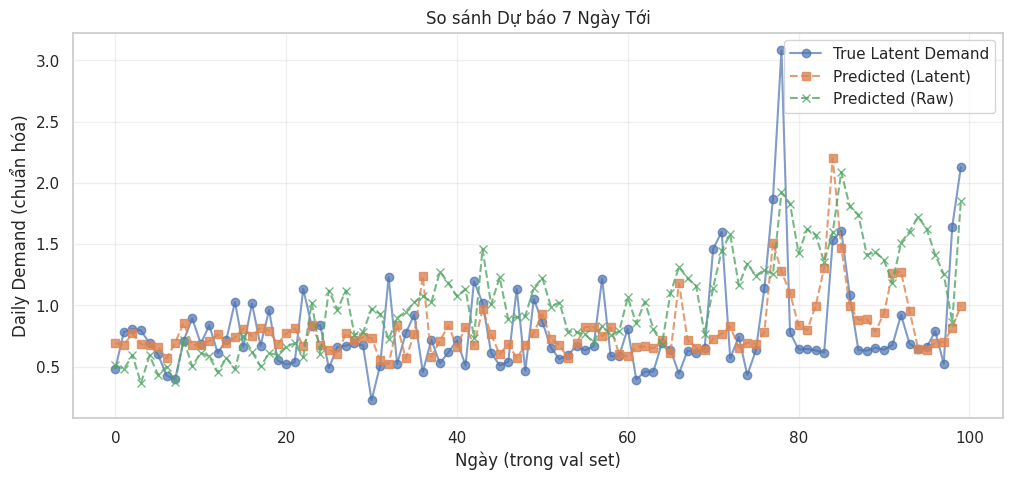

In [6]:
# Cell: Task 2 - Censoring-Robust Demand Forecasting (ĐÚNG CÁCH)

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

print("=== TASK 2: CENSORING-ROBUST DEMAND FORECASTING (ĐÚNG CÁCH) ===\n")

# 1. Chuẩn bị dữ liệu từ kết quả Task 1
df_sample = df_train.head(2000).copy()

# Tính daily latent demand từ Y_pred (chỉ 6h–22h)
daily_latent = Y_pred[:, 6:23].sum(axis=1)  # (2000,)
df_sample['daily_latent_demand'] = daily_latent

# Tính daily observed sales (để so sánh)
observed_daily = []
for _, row in df_sample.iterrows():
    sales_6_22 = np.array(row['hours_sale'])[6:23]
    observed_daily.append(sales_6_22.sum())
df_sample['daily_observed_sales'] = np.array(observed_daily)

# 2. Chuẩn bị features cho dự báo 7 ngày tới
# Dùng sliding window: 7 ngày lịch sử → dự báo ngày thứ 8
def create_sequences(series, lookback=7):
    X, y = [], []
    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# Dùng latent demand để train
X_latent, y_latent = create_sequences(df_sample['daily_latent_demand'].values, lookback=7)
# Dùng observed sales để so sánh
X_obs, y_obs = create_sequences(df_sample['daily_observed_sales'].values, lookback=7)

# Chuẩn bị covariates: discount, weather trung bình trong 7 ngày
covariates = ['discount', 'precpt', 'avg_temperature', 'holiday_flag']
X_cov = []
for i in range(7, len(df_sample)):
    window = df_sample.iloc[i-7:i][covariates].mean().values
    X_cov.append(window)
X_cov = np.array(X_cov)

# Gộp features
X_latent_full = np.concatenate([X_latent, X_cov], axis=1)
X_obs_full = np.concatenate([X_obs, X_cov], axis=1)

# Chia train/val (80/20)
split = int(0.8 * len(X_latent_full))
X_train_latent, X_val_latent = X_latent_full[:split], X_latent_full[split:]
y_train_latent, y_val_latent = y_latent[:split], y_latent[split:]

X_train_obs, X_val_obs = X_obs_full[:split], X_obs_full[split:]
y_train_obs, y_val_obs = y_obs[:split], y_obs[split:]

# 3. Huấn luyện mô hình (Random Forest — mạnh hơn Linear cho pattern phi tuyến)
model_latent = RandomForestRegressor(n_estimators=100, random_state=42)
model_latent.fit(X_train_latent, y_train_latent)

model_obs = RandomForestRegressor(n_estimators=100, random_state=42)
model_obs.fit(X_train_obs, y_train_obs)

# 4. Dự báo & đánh giá
pred_latent = model_latent.predict(X_val_latent)
pred_obs = model_obs.predict(X_val_obs)

mae_latent = mean_absolute_error(y_val_latent, pred_latent)
mae_obs = mean_absolute_error(y_val_obs, pred_obs)

print(f"MAE (dùng latent demand): {mae_latent:.4f}")
print(f"MAE (dùng raw sales): {mae_obs:.4f}")
print(f"Cải thiện: {(mae_obs - mae_latent) / mae_obs:.2%}")

# 5. Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 5))
plt.plot(y_val_latent[:100], 'o-', label='True Latent Demand', alpha=0.7)
plt.plot(pred_latent[:100], 's--', label='Predicted (Latent)', alpha=0.8)
plt.plot(pred_obs[:100], 'x--', label='Predicted (Raw)', alpha=0.8)
plt.title('So sánh Dự báo 7 Ngày Tới')
plt.xlabel('Ngày (trong val set)')
plt.ylabel('Daily Demand (chuẩn hóa)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Cell: Prescriptive Engine - Phiên bản đúng (không cần true demand)

import pandas as pd
import numpy as np

print("=== PRESCRIPTIVE ENGINE (PHIÊN BẢN ĐÚNG) ===\n")

# Lấy predicted demand từ Task 2
df_val = df_sample.iloc[-len(pred_latent):].copy()
df_val['predicted_demand'] = pred_latent

# Xác định ngưỡng dựa trên phân vị (không dùng true demand!)
demand_quantiles = np.quantile(pred_latent, [0.25, 0.75])
low_threshold = demand_quantiles[0]   # 25%
high_threshold = demand_quantiles[1]  # 75%

print(f"Ngưỡng demand:")
print(f"- Thấp: < {low_threshold:.3f}")
print(f"- Cao: > {high_threshold:.3f}\n")

# Gợi ý hành động
actions = []
for i in range(len(df_val)):
    pred = pred_latent[i]
    stockout_cnt = df_val.iloc[i]['stock_hour6_22_cnt']  # số giờ stockout trong ngày

    if pred > high_threshold:
        if stockout_cnt > 3:  # thường xuyên hết hàng
            action = "🔥 Demand cao + thường stockout → TĂNG NHẬP 150%"
        else:
            action = "📈 Demand cao → Duy trì hoặc tăng 20% tồn"
    elif pred < low_threshold:
        action = "📉 Demand thấp → Giảm giá 10% hoặc giảm nhập"
    else:
        action = "✅ Demand trung bình → Duy trì"

    actions.append(action)

df_val['action'] = actions

# Hiển thị kết quả
print("Ví dụ 5 dòng đầu:")
print(df_val[['dt', 'predicted_demand', 'stock_hour6_22_cnt', 'action']].head(5).to_string(index=False))

# Thống kê phân bố hành động
action_counts = pd.Series(actions).value_counts()
print("\nPhân bố hành động:")
print(action_counts)

=== PRESCRIPTIVE ENGINE (PHIÊN BẢN ĐÚNG) ===

Ngưỡng demand:
- Thấp: < 0.677
- Cao: > 0.821

Ví dụ 5 dòng đầu:
        dt  predicted_demand  stock_hour6_22_cnt                                      action
2024-06-07          0.690056                   8               ✅ Demand trung bình → Duy trì
2024-06-08          0.678279                   0               ✅ Demand trung bình → Duy trì
2024-06-09          0.771482                   0               ✅ Demand trung bình → Duy trì
2024-06-10          0.683058                   0               ✅ Demand trung bình → Duy trì
2024-06-11          0.676810                   2 📉 Demand thấp → Giảm giá 10% hoặc giảm nhập

Phân bố hành động:
✅ Demand trung bình → Duy trì                      199
📉 Demand thấp → Giảm giá 10% hoặc giảm nhập        100
📈 Demand cao → Duy trì hoặc tăng 20% tồn            57
🔥 Demand cao + thường stockout → TĂNG NHẬP 150%     43
Name: count, dtype: int64
